In [57]:
import matplotlib.pyplot as plt
import numpy as np

In [58]:
M_max = 1

M_values = np.linspace(-M_max, M_max, 1000)
m_values = np.linspace(-M_max, M_max, 1000)
M_mesh, m_mesh = np.meshgrid(M_values, m_values, indexing="ij")

In [59]:
def f1(M, m, eps):
    delta = M - m
    lb = m - eps * delta
    ub = M + eps * delta
    return lb, ub


def f2(M, m, eps):
    lb = m - eps * np.abs(m)
    ub = M + eps * np.abs(M)
    return lb, ub

In [60]:
lb1, ub1 = f1(M_mesh, m_mesh, 1e-2)
lb1 = np.where(M_mesh < m_mesh, np.nan, lb1)
ub1 = np.where(M_mesh < m_mesh, np.nan, ub1)

lb2, ub2 = f2(M_mesh, m_mesh, 1e-5)
lb2 = np.where(M_mesh < m_mesh, np.nan, lb2)
ub2 = np.where(M_mesh < m_mesh, np.nan, ub2)

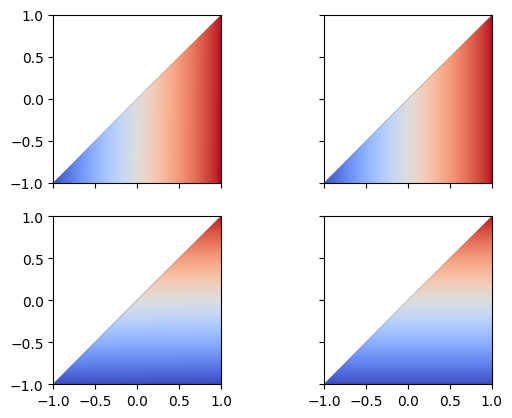

In [61]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)

vmax = np.nanmax([np.abs(a) for a in [lb1, ub1, lb2, ub2]])

style = dict(
    vmin=-vmax,
    vmax=vmax,
    origin="lower",
    cmap="coolwarm",
    extent=(M_values.min(), M_values.max(), m_values.min(), m_values.max()),
)
axs[0, 0].imshow(ub1.T, **style)
axs[1, 0].imshow(lb1.T, **style)
axs[0, 1].imshow(ub2.T, **style)
axs[1, 1].imshow(lb2.T, **style)

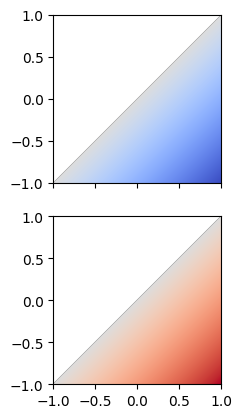

In [62]:
fig, axs = plt.subplots(2, 1, sharex=True, sharey=True)

dvmax = np.nanmax([np.abs(a) for a in [ub2 - ub1, lb2 - lb1]])

style = dict(
    vmin=-dvmax,
    vmax=dvmax,
    origin="lower",
    cmap="coolwarm",
    extent=(M_values.min(), M_values.max(), m_values.min(), m_values.max()),
)
axs[0].imshow((ub2 - ub1).T, **style)
axs[1].imshow((lb2 - lb1).T, **style)

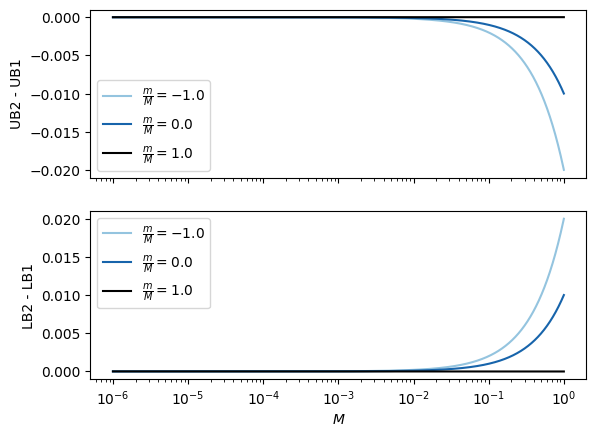

In [63]:
M_values = np.linspace(1e-6, 1, 10000)
m_over_M_values = np.array([-1.0, 0.0, 1.0])

cmap = plt.get_cmap("Blues")
colors = {-1.0: cmap(0.4), 0: cmap(0.8), 1: "k"}

# fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
fig, axs = plt.subplots(2, 1, sharex=True, sharey="row")
axs[1].set_xlabel(r"$M$")
axs[1].set_xscale("log")
axs[0].set_ylabel("UB2 - UB1")
axs[1].set_ylabel("LB2 - LB1")
# axs[0].set_ylim(-0.025, 0.001)
# axs[1].set_ylim(-0.001, 0.025)

for m_over_M in m_over_M_values:
    M = M_values
    m = m_over_M * M

    if np.any(m > M):
        raise ValueError("m must be less than or equal to M")

    lb1, ub1 = f1(M, m, 1e-2)
    lb2, ub2 = f2(M, m, 1e-5)

    # cmap = plt.get_cmap('viridis')
    # color= 'k' if dM == 0 else cmap(np.log10(-dM) / np.log10(-dM_values.min()))

    axs[0].plot(
        M,
        (ub2 - ub1),
        label=r"$\frac{{m}}{{M}}=" + f"{m_over_M}$",
        color=colors[m_over_M],
    )
    axs[1].plot(
        M,
        (lb2 - lb1),
        label=r"$\frac{{m}}{{M}}=" + f"{m_over_M}$",
        color=colors[m_over_M],
    )

    # axs[0].plot(M, ub1 / M, label=r"$\frac{{m}}{{M}}="+f"{m_over_M}$", color=colors[m_over_M])
    # axs[0].plot(M, ub2 / M, label=r"$\frac{{m}}{{M}}="+f"{m_over_M}$", color=colors[m_over_M], linestyle='--')
    # axs[1].plot(M, lb1 / M, label=r"$\frac{{m}}{{M}}="+f"{m_over_M}$", color=colors[m_over_M])
    # axs[1].plot(M, lb2 / M, label=r"$\frac{{m}}{{M}}="+f"{m_over_M}$", color=colors[m_over_M], linestyle='--')

axs[0].legend()
axs[1].legend()